In [2]:
import pandas as pd
import numpy as np

lab_event_path = '/media/Volume/data/MIMIC_IV/labevents.csv.gz'
lab_item_path = '/media/Volume/data/MIMIC_IV/d_labitems.csv.gz'
exams_path = '/media/Volume/data/MIMIC_IV/exams_filtered.csv'
out_path = '/media/Volume/data/MIMIC_IV/lab_events_encoded.csv'

hrs_margin = 1

In [3]:
# Load the labevents.csv.gz file using Dask
labevent = pd.read_csv(lab_event_path)
labevent.head()

,labevent_id,subject_id,hadm_id,specimen_id,itemid,order_provider_id,charttime,storetime,value,valuenum,valueuom,ref_range_lower,ref_range_upper,flag,priority,comments
0,1,10000032,NaN,2704548,50931,P69FQC,2180-03-23 11:51:00,2180-03-23 15:56:00,___,95.0,mg/dL,70.0,100.0,NaN,ROUTINE,"IF FASTING, 70-100 NORMAL, >125 PROVISIONAL DI..."
1,2,10000032,NaN,36092842,51071,P69FQC,2180-03-23 11:51:00,2180-03-23 16:00:00,NEG,NaN,NaN,NaN,NaN,NaN,ROUTINE,NaN
2,3,10000032,NaN,36092842,51074,P69FQC,2180-03-23 11:51:00,2180-03-23 16:00:00,NEG,NaN,NaN,NaN,NaN,NaN,ROUTINE,NaN
3,4,10000032,NaN,36092842,51075,P69FQC,2180-03-23 11:51:00,2180-03-23 16:00:00,NEG,NaN,NaN,NaN,NaN,NaN,ROUTINE,BENZODIAZEPINE IMMUNOASSAY SCREEN DOES NOT DET...
4,5,10000032,NaN,36092842,51079,P69FQC,2180-03-23 11:51:00,2180-03-23 16:00:00,NEG,NaN,NaN,NaN,NaN,NaN,ROUTINE,NaN


In [4]:
labitem = pd.read_csv(lab_item_path)

# keep only fluid == blood
labitem = labitem[labitem['fluid'].str.lower() == 'blood']
labitem.head()

,itemid,label,fluid,category
0,50801,Alveolar-arterial Gradient,Blood,Blood Gas
1,50802,Base Excess,Blood,Blood Gas
2,50803,"Calculated Bicarbonate, Whole Blood",Blood,Blood Gas
3,50804,Calculated Total CO2,Blood,Blood Gas
4,50805,Carboxyhemoglobin,Blood,Blood Gas


In [5]:
label_list = ['NTproBNP', 'Urea Nitrogen', 'Hemoglobin', 'Creatinine',
             'Ferritin', 'Hematocrit', 'Albumin', 'RDW-SD', 'Anion Gap',
             'RDW', 'Bicarbonate', 'Bilirubin, Total', 'INR(PT)',
             'Red Blood Cells', 'PT', 'Creatine Kinase (CK)', 'MCHC',
             'Calcium, Total', 'Lymphocytes']

label_fds = []
for label in label_list:
    label_fds.append(labitem[labitem['label'] == label])
    print(f"\n{label} item ID:", label_fds[-1])


NTproBNP item ID:      itemid     label  fluid   category
160   50963  NTproBNP  Blood  Chemistry

Urea Nitrogen item ID:       itemid          label  fluid   category
202    51006  Urea Nitrogen  Blood  Chemistry
1529   52647  Urea Nitrogen  Blood  Chemistry

Hemoglobin item ID:      itemid       label  fluid    category
9     50811  Hemoglobin  Blood   Blood Gas
407   51222  Hemoglobin  Blood  Hematology
762   51640  Hemoglobin  Blood   Chemistry

Creatinine item ID:       itemid       label  fluid   category
110    50912  Creatinine  Blood  Chemistry
1521   52546  Creatinine  Blood  Chemistry

Ferritin item ID:      itemid     label  fluid   category
122   50924  Ferritin  Blood  Chemistry

Hematocrit item ID:       itemid       label  fluid    category
406    51221  Hematocrit  Blood  Hematology
760    51638  Hematocrit  Blood   Chemistry
761    51639  Hematocrit  Blood   Chemistry
1118   52028  Hematocrit  Blood   Blood Gas

Albumin item ID:       itemid    label  fluid   categor

In [6]:
item_ids_to_keep = pd.concat(label_fds).drop_duplicates()

print("\nItem IDs to keep:")
item_ids_to_keep.head(n=200)


Item IDs to keep:


,itemid,label,fluid,category
160,50963,NTproBNP,Blood,Chemistry
202,51006,Urea Nitrogen,Blood,Chemistry
1529,52647,Urea Nitrogen,Blood,Chemistry
9,50811,Hemoglobin,Blood,Blood Gas
407,51222,Hemoglobin,Blood,Hematology
762,51640,Hemoglobin,Blood,Chemistry
110,50912,Creatinine,Blood,Chemistry
1521,52546,Creatinine,Blood,Chemistry
122,50924,Ferritin,Blood,Chemistry
406,51221,Hematocrit,Blood,Hematology


In [7]:
filtered_labevent = labevent[labevent['itemid'].isin(item_ids_to_keep['itemid'])]
# drop nan on valuenum
filtered_labevent = filtered_labevent.dropna(subset=['valuenum', 'charttime'])
print("\nFiltered labevent DataFrame:")
filtered_labevent.head(n=10)


Filtered labevent DataFrame:


,labevent_id,subject_id,hadm_id,specimen_id,itemid,order_provider_id,charttime,storetime,value,valuenum,valueuom,ref_range_lower,ref_range_upper,flag,priority,comments
11,12,10000032,NaN,83925500,50862,P69FQC,2180-03-23 11:51:00,2180-03-23 16:40:00,3.3,3.3,g/dL,3.5,5.2,abnormal,ROUTINE,NaN
14,15,10000032,NaN,83925500,50868,P69FQC,2180-03-23 11:51:00,2180-03-23 16:40:00,12,12.0,mEq/L,8.0,20.0,NaN,ROUTINE,NaN
16,17,10000032,NaN,83925500,50882,P69FQC,2180-03-23 11:51:00,2180-03-23 16:40:00,27,27.0,mEq/L,22.0,32.0,NaN,ROUTINE,NaN
17,18,10000032,NaN,83925500,50885,P69FQC,2180-03-23 11:51:00,2180-03-23 16:40:00,1.6,1.6,mg/dL,0.0,1.5,abnormal,ROUTINE,NaN
18,19,10000032,NaN,83925500,50893,P69FQC,2180-03-23 11:51:00,2180-03-23 16:40:00,8.4,8.4,mg/dL,8.4,10.3,NaN,ROUTINE,NaN
25,26,10000032,NaN,83925500,50912,P69FQC,2180-03-23 11:51:00,2180-03-23 16:40:00,0.4,0.4,mg/dL,0.4,1.1,NaN,ROUTINE,NaN
28,29,10000032,NaN,83925500,50924,P69FQC,2180-03-23 11:51:00,2180-03-23 16:40:00,90,90.0,ng/mL,13.0,150.0,NaN,ROUTINE,NaN
45,46,10000032,NaN,83925500,51006,P69FQC,2180-03-23 11:51:00,2180-03-23 16:40:00,13,13.0,mg/dL,6.0,20.0,NaN,ROUTINE,NaN
46,47,10000032,NaN,87340659,51237,P69FQC,2180-03-23 11:51:00,2180-03-23 15:15:00,1.4,1.4,NaN,0.9,1.1,abnormal,ROUTINE,NaN
47,48,10000032,NaN,87340659,51274,P69FQC,2180-03-23 11:51:00,2180-03-23 15:15:00,___,15.1,sec,9.4,12.5,abnormal,ROUTINE,VERIFIED.


In [8]:
# chech for every row that if valuenum is not in the range ref_range_lower and ref_range_upper flag is marked as abnormal
filtered_labevent['below_lower_range'] = np.where(
    (filtered_labevent['valuenum'] < filtered_labevent['ref_range_lower']),
    True,
    False
)
filtered_labevent['above_upper_range'] = np.where(
    (filtered_labevent['valuenum'] > filtered_labevent['ref_range_upper']),
    True,
    False
)

filtered_labevent.head(n=10)

,labevent_id,subject_id,hadm_id,specimen_id,itemid,order_provider_id,charttime,storetime,value,valuenum,valueuom,ref_range_lower,ref_range_upper,flag,priority,comments,below_lower_range,above_upper_range
11,12,10000032,NaN,83925500,50862,P69FQC,2180-03-23 11:51:00,2180-03-23 16:40:00,3.3,3.3,g/dL,3.5,5.2,abnormal,ROUTINE,NaN,True,False
14,15,10000032,NaN,83925500,50868,P69FQC,2180-03-23 11:51:00,2180-03-23 16:40:00,12,12.0,mEq/L,8.0,20.0,NaN,ROUTINE,NaN,False,False
16,17,10000032,NaN,83925500,50882,P69FQC,2180-03-23 11:51:00,2180-03-23 16:40:00,27,27.0,mEq/L,22.0,32.0,NaN,ROUTINE,NaN,False,False
17,18,10000032,NaN,83925500,50885,P69FQC,2180-03-23 11:51:00,2180-03-23 16:40:00,1.6,1.6,mg/dL,0.0,1.5,abnormal,ROUTINE,NaN,False,True
18,19,10000032,NaN,83925500,50893,P69FQC,2180-03-23 11:51:00,2180-03-23 16:40:00,8.4,8.4,mg/dL,8.4,10.3,NaN,ROUTINE,NaN,False,False
25,26,10000032,NaN,83925500,50912,P69FQC,2180-03-23 11:51:00,2180-03-23 16:40:00,0.4,0.4,mg/dL,0.4,1.1,NaN,ROUTINE,NaN,False,False
28,29,10000032,NaN,83925500,50924,P69FQC,2180-03-23 11:51:00,2180-03-23 16:40:00,90,90.0,ng/mL,13.0,150.0,NaN,ROUTINE,NaN,False,False
45,46,10000032,NaN,83925500,51006,P69FQC,2180-03-23 11:51:00,2180-03-23 16:40:00,13,13.0,mg/dL,6.0,20.0,NaN,ROUTINE,NaN,False,False
46,47,10000032,NaN,87340659,51237,P69FQC,2180-03-23 11:51:00,2180-03-23 15:15:00,1.4,1.4,NaN,0.9,1.1,abnormal,ROUTINE,NaN,False,True
47,48,10000032,NaN,87340659,51274,P69FQC,2180-03-23 11:51:00,2180-03-23 15:15:00,___,15.1,sec,9.4,12.5,abnormal,ROUTINE,VERIFIED.,False,True


In [9]:
# for each itemid show the ref_range_lower and ref_range_upper
# group by itemid and aggregate the ref_range_lower and ref_range_upper
ref_ranges = filtered_labevent.groupby('itemid').agg({
    'ref_range_lower': 'median',
    'ref_range_upper': 'median',
    'valueuom': 'first',
    'valuenum': 'count'
}).reset_index()
print("\nReference Ranges for each item ID:")

# merge with event names
ref_ranges = ref_ranges.merge(labitem[['itemid', 'label']], on='itemid', how='left')
# order by label
ref_ranges = ref_ranges.sort_values(by='label').reset_index(drop=True)

ref_ranges.rename(columns={'label': 'item_label', 'valuenum': 'item_count'}, inplace=True)

ref_ranges.head(n=100)


Reference Ranges for each item ID:


,itemid,ref_range_lower,ref_range_upper,valueuom,item_count,item_label
0,50862,3.5,5.2,g/dL,1032267,Albumin
1,53085,3.3,5.5,mg/dL,69,Albumin
2,50868,8.0,20.0,mEq/L,3925442,Anion Gap
3,52500,8.0,16.0,mEq/L,1230,Anion Gap
4,50882,22.0,32.0,mEq/L,3933274,Bicarbonate
5,53089,0.2,1.6,mg/dL,69,"Bilirubin, Total"
6,50885,0.0,1.5,mg/dL,1576045,"Bilirubin, Total"
7,50893,8.4,10.3,mg/dL,2969098,"Calcium, Total"
8,50910,38.0,201.0,IU/L,334591,Creatine Kinase (CK)
9,50912,0.5,1.2,mg/dL,4317525,Creatinine


In [10]:
# remove duplicates keeping the max item_count on column item_label
ref_ranges = ref_ranges.sort_values(by='item_count', ascending=False).drop_duplicates(subset=['item_label'])
ref_ranges = ref_ranges.sort_values(by='item_label').reset_index(drop=True)
print("\nFiltered Reference Ranges with item count > 100:")
ref_ranges.head(n=100)


Filtered Reference Ranges with item count > 100:


,itemid,ref_range_lower,ref_range_upper,valueuom,item_count,item_label
0,50862,3.5,5.2,g/dL,1032267,Albumin
1,50868,8.0,20.0,mEq/L,3925442,Anion Gap
2,50882,22.0,32.0,mEq/L,3933274,Bicarbonate
3,50885,0.0,1.5,mg/dL,1576045,"Bilirubin, Total"
4,50893,8.4,10.3,mg/dL,2969098,"Calcium, Total"
5,50910,38.0,201.0,IU/L,334591,Creatine Kinase (CK)
6,50912,0.5,1.2,mg/dL,4317525,Creatinine
7,50924,13.0,150.0,ng/mL,189548,Ferritin
8,51221,36.0,48.0,%,4320694,Hematocrit
9,51222,12.0,16.0,g/dL,4172454,Hemoglobin


In [11]:
filtered_labevent = filtered_labevent.merge(ref_ranges[['itemid', 'item_label']], on='itemid', how='left')
filtered_labevent.dropna(subset=['valuenum', 'charttime'], inplace=True)
filtered_labevent.head(n=10)

,labevent_id,subject_id,hadm_id,specimen_id,itemid,order_provider_id,charttime,storetime,value,valuenum,valueuom,ref_range_lower,ref_range_upper,flag,priority,comments,below_lower_range,above_upper_range,item_label
0,12,10000032,NaN,83925500,50862,P69FQC,2180-03-23 11:51:00,2180-03-23 16:40:00,3.3,3.3,g/dL,3.5,5.2,abnormal,ROUTINE,NaN,True,False,Albumin
1,15,10000032,NaN,83925500,50868,P69FQC,2180-03-23 11:51:00,2180-03-23 16:40:00,12,12.0,mEq/L,8.0,20.0,NaN,ROUTINE,NaN,False,False,Anion Gap
2,17,10000032,NaN,83925500,50882,P69FQC,2180-03-23 11:51:00,2180-03-23 16:40:00,27,27.0,mEq/L,22.0,32.0,NaN,ROUTINE,NaN,False,False,Bicarbonate
3,18,10000032,NaN,83925500,50885,P69FQC,2180-03-23 11:51:00,2180-03-23 16:40:00,1.6,1.6,mg/dL,0.0,1.5,abnormal,ROUTINE,NaN,False,True,"Bilirubin, Total"
4,19,10000032,NaN,83925500,50893,P69FQC,2180-03-23 11:51:00,2180-03-23 16:40:00,8.4,8.4,mg/dL,8.4,10.3,NaN,ROUTINE,NaN,False,False,"Calcium, Total"
5,26,10000032,NaN,83925500,50912,P69FQC,2180-03-23 11:51:00,2180-03-23 16:40:00,0.4,0.4,mg/dL,0.4,1.1,NaN,ROUTINE,NaN,False,False,Creatinine
6,29,10000032,NaN,83925500,50924,P69FQC,2180-03-23 11:51:00,2180-03-23 16:40:00,90,90.0,ng/mL,13.0,150.0,NaN,ROUTINE,NaN,False,False,Ferritin
7,46,10000032,NaN,83925500,51006,P69FQC,2180-03-23 11:51:00,2180-03-23 16:40:00,13,13.0,mg/dL,6.0,20.0,NaN,ROUTINE,NaN,False,False,Urea Nitrogen
8,47,10000032,NaN,87340659,51237,P69FQC,2180-03-23 11:51:00,2180-03-23 15:15:00,1.4,1.4,NaN,0.9,1.1,abnormal,ROUTINE,NaN,False,True,INR(PT)
9,48,10000032,NaN,87340659,51274,P69FQC,2180-03-23 11:51:00,2180-03-23 15:15:00,___,15.1,sec,9.4,12.5,abnormal,ROUTINE,VERIFIED.,False,True,PT


In [12]:
filtered_labevent = filtered_labevent[filtered_labevent['item_label'].notnull()]
filtered_labevent.head(n=10)

,labevent_id,subject_id,hadm_id,specimen_id,itemid,order_provider_id,charttime,storetime,value,valuenum,valueuom,ref_range_lower,ref_range_upper,flag,priority,comments,below_lower_range,above_upper_range,item_label
0,12,10000032,NaN,83925500,50862,P69FQC,2180-03-23 11:51:00,2180-03-23 16:40:00,3.3,3.3,g/dL,3.5,5.2,abnormal,ROUTINE,NaN,True,False,Albumin
1,15,10000032,NaN,83925500,50868,P69FQC,2180-03-23 11:51:00,2180-03-23 16:40:00,12,12.0,mEq/L,8.0,20.0,NaN,ROUTINE,NaN,False,False,Anion Gap
2,17,10000032,NaN,83925500,50882,P69FQC,2180-03-23 11:51:00,2180-03-23 16:40:00,27,27.0,mEq/L,22.0,32.0,NaN,ROUTINE,NaN,False,False,Bicarbonate
3,18,10000032,NaN,83925500,50885,P69FQC,2180-03-23 11:51:00,2180-03-23 16:40:00,1.6,1.6,mg/dL,0.0,1.5,abnormal,ROUTINE,NaN,False,True,"Bilirubin, Total"
4,19,10000032,NaN,83925500,50893,P69FQC,2180-03-23 11:51:00,2180-03-23 16:40:00,8.4,8.4,mg/dL,8.4,10.3,NaN,ROUTINE,NaN,False,False,"Calcium, Total"
5,26,10000032,NaN,83925500,50912,P69FQC,2180-03-23 11:51:00,2180-03-23 16:40:00,0.4,0.4,mg/dL,0.4,1.1,NaN,ROUTINE,NaN,False,False,Creatinine
6,29,10000032,NaN,83925500,50924,P69FQC,2180-03-23 11:51:00,2180-03-23 16:40:00,90,90.0,ng/mL,13.0,150.0,NaN,ROUTINE,NaN,False,False,Ferritin
7,46,10000032,NaN,83925500,51006,P69FQC,2180-03-23 11:51:00,2180-03-23 16:40:00,13,13.0,mg/dL,6.0,20.0,NaN,ROUTINE,NaN,False,False,Urea Nitrogen
8,47,10000032,NaN,87340659,51237,P69FQC,2180-03-23 11:51:00,2180-03-23 15:15:00,1.4,1.4,NaN,0.9,1.1,abnormal,ROUTINE,NaN,False,True,INR(PT)
9,48,10000032,NaN,87340659,51274,P69FQC,2180-03-23 11:51:00,2180-03-23 15:15:00,___,15.1,sec,9.4,12.5,abnormal,ROUTINE,VERIFIED.,False,True,PT


In [13]:
ecgs_raw = pd.read_csv(exams_path)
ecgs_raw.head()

,Unnamed: 0,file_name,study_id,subject_id,ecg_time,ed_stay_id,ed_hadm_id,hosp_hadm_id,ed_diag_ed,ed_diag_hosp,...,age,anchor_year,anchor_age,dod,ecg_no_within_stay,ecg_taken_in_ed,ecg_taken_in_hosp,ecg_taken_in_ed_or_hosp,fold,strat_fold
0,0,files/p1000/p10000032/s40689238/40689238,40689238,10000032,2180-07-23 08:44:00,39399961.0,29079034.0,NaN,"['R4182', 'G9340']","['F319', 'J449', 'B182', 'E871', 'V462', 'I958...",...,52.0,2180.0,52.0,2180-09-09,0,True,False,True,17,9
1,1,files/p1000/p10000032/s44458630/44458630,44458630,10000032,2180-07-23 09:54:00,39399961.0,29079034.0,NaN,"['R4182', 'G9340']","['F319', 'J449', 'B182', 'E871', 'V462', 'I958...",...,52.0,2180.0,52.0,2180-09-09,1,True,False,True,17,9
2,2,files/p1000/p10000032/s49036311/49036311,49036311,10000032,2180-08-06 09:07:00,NaN,NaN,25742920.0,[],[],...,52.0,2180.0,52.0,2180-09-09,0,False,True,True,17,9
3,3,files/p1000/p10000117/s45090959/45090959,45090959,10000117,2181-03-04 17:14:00,NaN,NaN,NaN,[],[],...,55.0,2174.0,48.0,NaN,-1,False,False,False,18,0
4,4,files/p1000/p10000117/s48446569/48446569,48446569,10000117,2183-09-18 13:52:00,33176849.0,27988844.0,NaN,"['S72092A', 'W1830XA']","['K219', 'F419', 'Z7901', 'Z87891', 'G43909', ...",...,57.0,2174.0,48.0,NaN,0,True,False,True,18,0


In [14]:
subject_set = set(filtered_labevent['subject_id']) & set(ecgs_raw['subject_id'])
lab_events = filtered_labevent[filtered_labevent['subject_id'].isin(subject_set)].copy()
ecgs = ecgs_raw[ecgs_raw['subject_id'].isin(subject_set)].copy()

lab_events['charttime'] = pd.to_datetime(lab_events['charttime'])
ecgs['ecg_time'] = pd.to_datetime(ecgs['ecg_time'])

lab_events.dropna(subset=['charttime'], inplace=True)
ecgs.dropna(subset=['ecg_time'], inplace=True)

#sort
lab_events.sort_values(by='charttime', inplace=True)
ecgs.sort_values(by='ecg_time', inplace=True)

# Now merge_asof
merged = pd.merge_asof(
    lab_events,  # LEFT: what you want to preserve (all lab events)
    ecgs,        # RIGHT: what you want to match to (ECGs)
    by='subject_id',
    left_on='charttime',   # Note: swapped these too
    right_on='ecg_time',   # Note: swapped these too
    direction='nearest',
    suffixes=('_lab', '_ecg')  # Explicitly control the suffixes
)

print("Merged columns:", merged.columns)
merged = merged[['subject_id', 'study_id', 'ecg_time', 'charttime', 'valuenum', 'file_name', 'flag', 'item_label', 'ref_range_lower', 'ref_range_upper']]

# add column difference between ecg_time and charttime in timedelta format
merged['time_diff'] = (merged['ecg_time'] - merged['charttime'])
merged.head()

Merged columns: Index(['labevent_id', 'subject_id', 'hadm_id', 'specimen_id', 'itemid',
       'order_provider_id', 'charttime', 'storetime', 'value', 'valuenum',
       'valueuom', 'ref_range_lower', 'ref_range_upper', 'flag', 'priority',
       'comments', 'below_lower_range', 'above_upper_range', 'item_label',
       'Unnamed: 0', 'file_name', 'study_id', 'ecg_time', 'ed_stay_id',
       'ed_hadm_id', 'hosp_hadm_id', 'ed_diag_ed', 'ed_diag_hosp',
       'hosp_diag_hosp', 'all_diag_hosp', 'all_diag_all', 'gender', 'age',
       'anchor_year', 'anchor_age', 'dod', 'ecg_no_within_stay',
       'ecg_taken_in_ed', 'ecg_taken_in_hosp', 'ecg_taken_in_ed_or_hosp',
       'fold', 'strat_fold'],
      dtype='object')


,subject_id,study_id,ecg_time,charttime,valuenum,file_name,flag,item_label,ref_range_lower,ref_range_upper,time_diff
0,14216592,44669168,2109-08-07 07:55:00,2109-01-15 16:39:00,37.8,files/p1421/p14216592/s44669168/44669168,abnormal,PT,9.4,12.5,203 days 15:16:00
1,14216592,44669168,2109-08-07 07:55:00,2109-01-15 16:39:00,3.4,files/p1421/p14216592/s44669168/44669168,abnormal,INR(PT),0.9,1.1,203 days 15:16:00
2,13971870,48635654,2111-09-07 12:58:00,2109-02-01 15:35:00,2.2,files/p1397/p13971870/s48635654/48635654,abnormal,INR(PT),0.9,1.1,947 days 21:23:00
3,13971870,48635654,2111-09-07 12:58:00,2109-02-01 15:35:00,22.7,files/p1397/p13971870/s48635654/48635654,abnormal,PT,10.4,13.1,947 days 21:23:00
4,14451627,42261409,2110-01-22 11:27:00,2109-02-11 10:25:00,10.4,files/p1445/p14451627/s42261409/42261409,abnormal,Hemoglobin,12.0,16.0,345 days 01:02:00


In [15]:
# there are multiple lab events of the same type for the same study_id, i want to keep only the closer in time_diff
merged['time_diff_abs'] = merged['time_diff'].abs()
merged = merged.sort_values(by=['study_id', 'item_label', 'time_diff_abs'])
merged = merged.drop_duplicates(subset=['study_id', 'item_label'], keep='first')

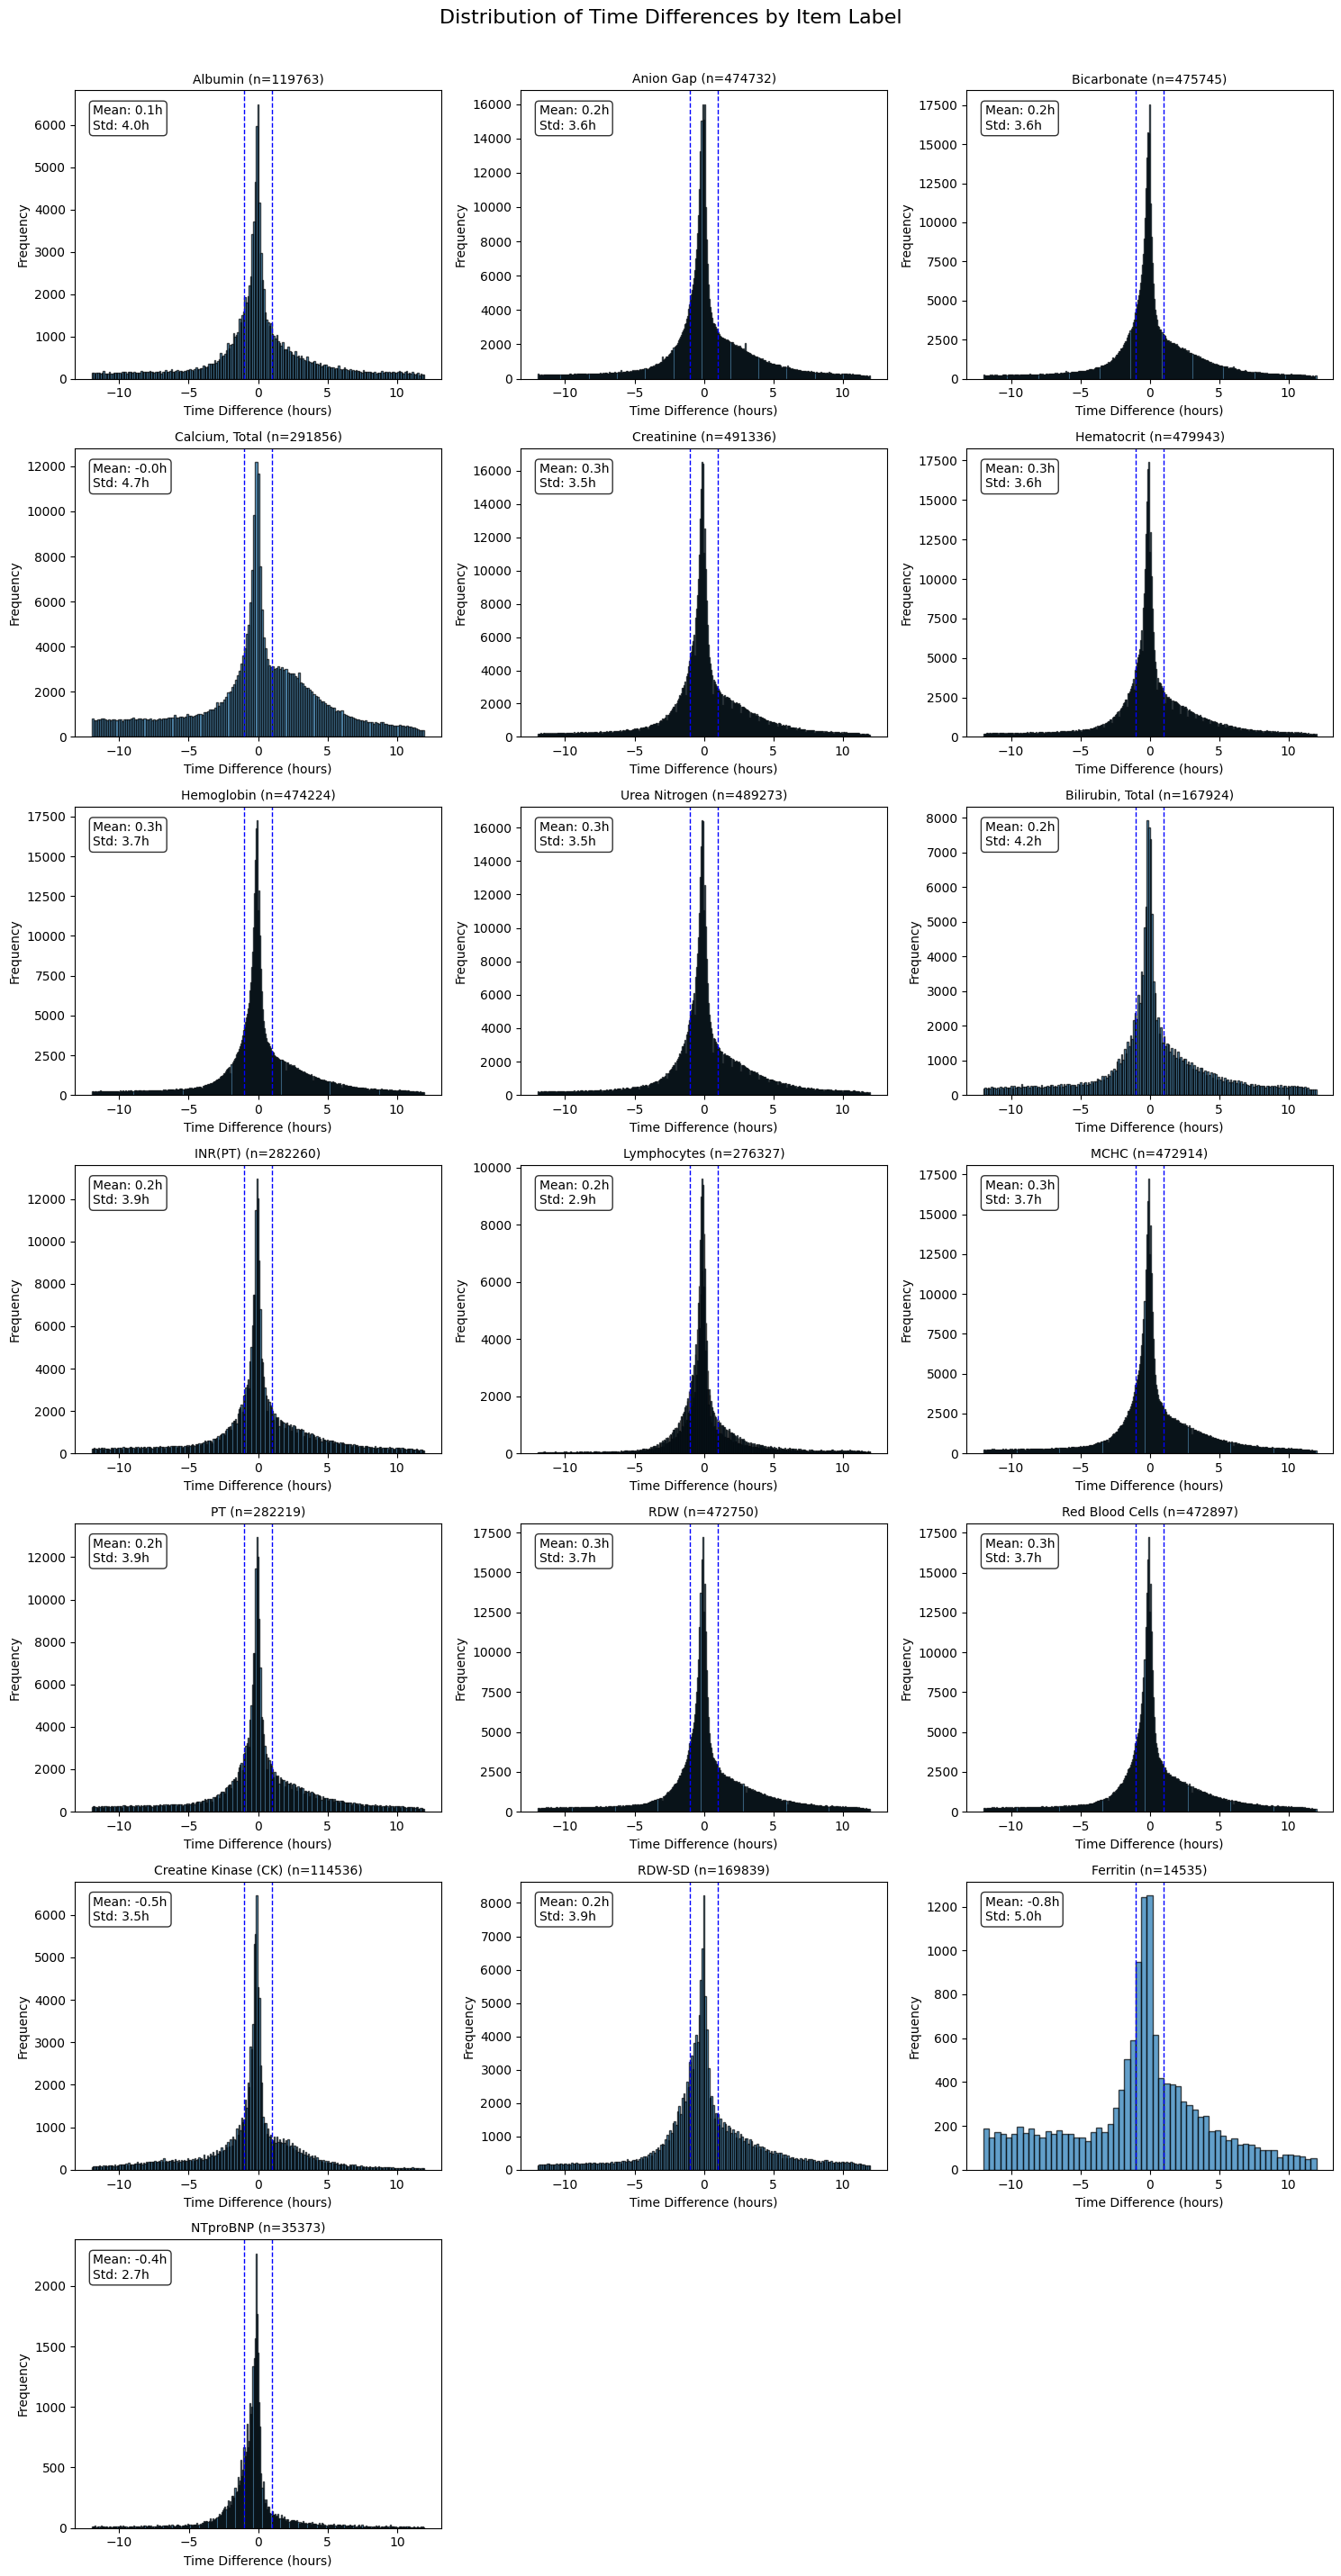

In [16]:
import matplotlib.pyplot as plt

unique_labels = merged['item_label'].unique()
merged['time_diff_hrs'] = merged['time_diff'].dt.total_seconds() / 3600  # Convert to hours
n_labels = len(unique_labels)

merged_12hrs = merged[merged['time_diff_hrs'].abs() <= 12]  # Filter for time differences within 12 hours

n_cols = min(3, n_labels)  # Maximum 3 columns
n_rows = (n_labels + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes_flat = axes.flatten() if n_rows > 1 else [axes]

grouped = merged_12hrs.groupby('item_label')['time_diff_hrs']
stats = grouped.agg(['count', 'mean', 'std', 'min', 'max'])

for i, label in enumerate(unique_labels):
    # Filter data for this label
    data = grouped.get_group(label)
    counts, bins, _ = axes_flat[i].hist(data, bins='auto', alpha=0.7, edgecolor='black')
    count = int(stats.loc[label, 'count'])

    axes_flat[i].set_title(f'{label} (n={count})', fontsize=10)
    axes_flat[i].set_xlabel('Time Difference (hours)')
    axes_flat[i].set_ylabel('Frequency')
    
    mean_val = stats.loc[label, 'mean']
    std_val = stats.loc[label, 'std']
    axes_flat[i].text(0.05, 0.95, f'Mean: {mean_val:.1f}h\nStd: {std_val:.1f}h', 
           transform=axes_flat[i].transAxes, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, pad=0.3))
    
    # plot two vertical lines at -2 and +2 
    axes_flat[i].axvline(x=-1, color='blue', linestyle='--', linewidth=1)
    axes_flat[i].axvline(x=1, color='blue', linestyle='--', linewidth=1)
    
# Hide empty subplots if any
for i in range(n_labels, len(axes_flat)):
    axes_flat[i].set_visible(False)

plt.tight_layout()
plt.suptitle('Distribution of Time Differences by Item Label', fontsize=16, y=1.02)
plt.show()

In [17]:
print("checking no duplicates on study_id and item_label")
merged_1hr = merged[merged['time_diff_hrs'].abs() <= 1]
ecg_vp = merged_1hr.groupby(['study_id', 'item_label'])
ecg_vp_counts = ecg_vp.size().reset_index(name='count')
ecg_vp_counts[ecg_vp_counts['count'] > 1].head(n=20)

checking no duplicates on study_id and item_label


,study_id,item_label,count


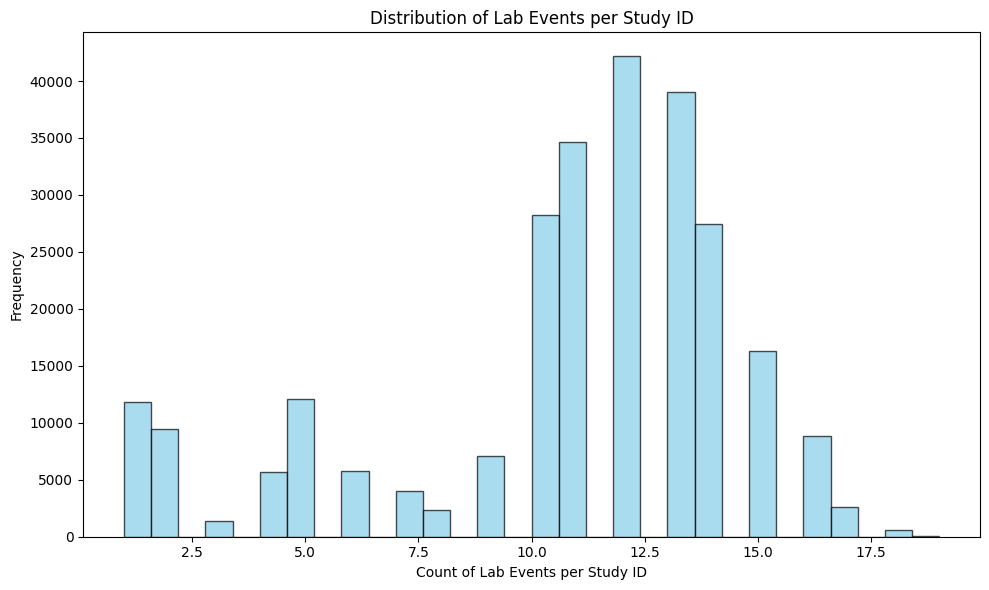

Maximum count of lab events per study_id: 19 for study_id: 40079405


In [18]:
ecg_vp = merged_1hr.groupby('study_id')

# plot the distribution of count of lab events
ecg_vp_counts = ecg_vp.size().reset_index(name='count')
plt.figure(figsize=(10, 6))
plt.hist(ecg_vp_counts['count'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('Count of Lab Events per Study ID')
plt.ylabel('Frequency')
plt.title('Distribution of Lab Events per Study ID')
plt.tight_layout()
plt.show()

# print the maximum count of lab events per study_id
max_count = ecg_vp_counts['count'].max()
max_study_id = ecg_vp_counts.loc[ecg_vp_counts['count'] == max_count, 'study_id'].values[0]
print(f'Maximum count of lab events per study_id: {max_count} for study_id: {max_study_id}')

In [19]:
def encode_value(row):
    value = row['valuenum']
    lower = row['ref_range_lower']
    upper = row['ref_range_upper']
    
    if pd.isna(value) or pd.isna(lower) or pd.isna(upper):
        return np.nan
    elif value < lower:
        return -1
    elif value > upper:
        return 1
    else:
        return 0
    
# Apply encoding
merged_encoded = merged_1hr.copy()
merged_encoded['encoded_value'] = merged_encoded.apply(encode_value, axis=1)

# Get all unique item_labels to create columns for all possible labels
all_item_labels = merged_encoded['item_label'].unique()

# Group by study_id and create pivot table
# First, let's keep other important columns (taking first occurrence per study_id)
study_info = merged_encoded.groupby('study_id').first()[['subject_id', 'ecg_time', 'charttime', 'file_name']].reset_index()

# Create pivot table with encoded values
pivot_df = merged_encoded.pivot_table(
    index='study_id',
    columns='item_label',
    values='encoded_value',
    aggfunc='first'  # In case of duplicates, take first
).reset_index()

result_df = study_info.merge(pivot_df, on='study_id', how='left')
result_df.head()


,study_id,subject_id,ecg_time,charttime,file_name,Albumin,Anion Gap,Bicarbonate,"Bilirubin, Total","Calcium, Total",...,Hemoglobin,INR(PT),Lymphocytes,MCHC,NTproBNP,PT,RDW,RDW-SD,Red Blood Cells,Urea Nitrogen
0,40000035,16598616,2126-04-01 19:32:00,2126-04-01 19:55:00,files/p1659/p16598616/s40000035/40000035,NaN,NaN,NaN,NaN,NaN,...,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
1,40000084,18370366,2179-08-30 11:58:00,2179-08-30 12:50:00,files/p1837/p18370366/s40000084/40000084,0.0,0.0,0.0,0.0,NaN,...,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0
2,40000089,15606157,2113-07-22 07:29:00,2113-07-22 07:15:00,files/p1560/p15606157/s40000089/40000089,NaN,0.0,-1.0,NaN,0.0,...,-1.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,-1.0,1.0
3,40000143,14691089,2175-07-21 01:01:00,2175-07-21 01:00:00,files/p1469/p14691089/s40000143/40000143,NaN,0.0,0.0,NaN,NaN,...,0.0,0.0,-1.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0
4,40000144,14144725,2160-02-09 13:57:00,2160-02-09 14:20:00,files/p1414/p14144725/s40000144/40000144,NaN,0.0,0.0,NaN,NaN,...,0.0,0.0,0.0,0.0,NaN,0.0,1.0,NaN,0.0,0.0


In [20]:
# save the result to a CSV file
result_df.to_csv(out_path, index=False)

In [21]:
row = result_df.iloc[0]
one_hot_values = row[label_list].fillna(-2)
one_hot_values = one_hot_values + 1
# print(one_hot_values)

encoding = {
    -1.0: [-1, -1, -1],
     0.0: [ 1,  0,  0],
     1.0: [ 0,  1,  0],
     2.0: [ 0,  0,  1]
}

# Map and expand into a DataFrame
encoded_df = pd.DataFrame(one_hot_values.map(encoding).to_list(),
                          index=one_hot_values.index,
                          columns=[i for i in range(3)])

print(encoded_df)

# flatten values
flattened_values = encoded_df.values.flatten()
print(flattened_values.tolist())

                      0  1  2
NTproBNP             -1 -1 -1
Urea Nitrogen        -1 -1 -1
Hemoglobin           -1 -1 -1
Creatinine           -1 -1 -1
Ferritin             -1 -1 -1
Hematocrit           -1 -1 -1
Albumin              -1 -1 -1
RDW-SD               -1 -1 -1
Anion Gap            -1 -1 -1
RDW                  -1 -1 -1
Bicarbonate          -1 -1 -1
Bilirubin, Total     -1 -1 -1
INR(PT)               0  1  0
Red Blood Cells      -1 -1 -1
PT                    0  1  0
Creatine Kinase (CK) -1 -1 -1
MCHC                 -1 -1 -1
Calcium, Total       -1 -1 -1
Lymphocytes          -1 -1 -1
[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 0, 1, 0, -1, -1, -1, 0, 1, 0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1]


/tmp/ipykernel_4900/3199308857.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  one_hot_values = row[label_list].fillna(-2)


In [22]:
# loading the xlstm model
import utils.utils as utils

config = utils.parse_config('configs/train_lab_run_config.yaml', 'config_defaults/train_mimic_config_defaults.yaml')
config.embedding_size = 1024
config.encoder_type = 'vanilla'
config.xlstm_config = ["s","s","m","m","s","s","m","m","s"]
config.checkpoint = 'train-lab/ojg53o86/checkpoints/epoch=19-step=6980.ckpt'
config.num_workers = 32
config.num_classes = len(config.label_list) * 3

# load mortality default config
model1 = utils.get_base_model(config)

config.checkpoint = 'train-lab/o423wka7/checkpoints/epoch=19-step=6980.ckpt'
model2 = utils.get_base_model(config)

config.checkpoint = 'train-lab/mo3flyav/checkpoints/epoch=19-step=6980.ckpt'
model3 = utils.get_base_model(config)

config.checkpoint = 'train-lab/22exycao/checkpoints/epoch=19-step=6980.ckpt'
model4 = utils.get_base_model(config)

config.checkpoint = 'train-lab/ojg53o86/checkpoints/epoch=19-step=6980.ckpt'
model5 = utils.get_base_model(config)

models = [model1, model2, model3, model4, model5]

/home/luna97/Research/MIT-BIH_ecg_arrhytmia/mit_bih_env/lib/python3.11/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


using linear patch embedding
creating xlstm with slstm at:  [0, 1, 4, 5, 8]
{'verbose': True, 'with_cuda': True, 'extra_ldflags': ['-L/usr/local/cuda-12.6/lib', '-lcublas'], 'extra_cflags': ['-DSLSTM_HIDDEN_SIZE=1024', '-DSLSTM_BATCH_SIZE=512', '-DSLSTM_NUM_HEADS=4', '-DSLSTM_NUM_STATES=4', '-DSLSTM_DTYPE_B=float', '-DSLSTM_DTYPE_R=__nv_bfloat16', '-DSLSTM_DTYPE_W=__nv_bfloat16', '-DSLSTM_DTYPE_G=__nv_bfloat16', '-DSLSTM_DTYPE_S=__nv_bfloat16', '-DSLSTM_DTYPE_A=float', '-DSLSTM_NUM_GATES=4', '-DSLSTM_SIMPLE_AGG=true', '-DSLSTM_GRADIENT_RECURRENT_CLIPVAL_VALID=false', '-DSLSTM_GRADIENT_RECURRENT_CLIPVAL=0.0', '-DSLSTM_FORWARD_CLIPVAL_VALID=false', '-DSLSTM_FORWARD_CLIPVAL=0.0', '-U__CUDA_NO_HALF_OPERATORS__', '-U__CUDA_NO_HALF_CONVERSIONS__', '-U__CUDA_NO_BFLOAT16_OPERATORS__', '-U__CUDA_NO_BFLOAT16_CONVERSIONS__', '-U__CUDA_NO_BFLOAT162_OPERATORS__', '-U__CUDA_NO_BFLOAT162_CONVERSIONS__'], 'extra_cuda_cflags': ['-Xptxas="-v"', '-gencode', 'arch=compute_80,code=compute_80', '-res-usage'

W0904 15:24:50.294000 4900 torch/utils/cpp_extension.py:2425] TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
W0904 15:24:50.294000 4900 torch/utils/cpp_extension.py:2425] If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'] to specific architectures.
/home/luna97/Research/MIT-BIH_ecg_arrhytmia/mit_bih_env/lib/python3.11/site-packages/xlstm/blocks/slstm/cell.py:543: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @conditional_decorator(
/home/luna97/Research/MIT-BIH_ecg_arrhytmia/mit_bih_env/lib/python3.11/site-packages/xlstm/blocks/slstm/cell.py:568: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @conditional_decorator(


ninja: no work to do.
{'verbose': True, 'with_cuda': True, 'extra_ldflags': ['-L/usr/local/cuda-12.6/lib', '-lcublas'], 'extra_cflags': ['-DSLSTM_HIDDEN_SIZE=1024', '-DSLSTM_BATCH_SIZE=512', '-DSLSTM_NUM_HEADS=4', '-DSLSTM_NUM_STATES=4', '-DSLSTM_DTYPE_B=float', '-DSLSTM_DTYPE_R=__nv_bfloat16', '-DSLSTM_DTYPE_W=__nv_bfloat16', '-DSLSTM_DTYPE_G=__nv_bfloat16', '-DSLSTM_DTYPE_S=__nv_bfloat16', '-DSLSTM_DTYPE_A=float', '-DSLSTM_NUM_GATES=4', '-DSLSTM_SIMPLE_AGG=true', '-DSLSTM_GRADIENT_RECURRENT_CLIPVAL_VALID=false', '-DSLSTM_GRADIENT_RECURRENT_CLIPVAL=0.0', '-DSLSTM_FORWARD_CLIPVAL_VALID=false', '-DSLSTM_FORWARD_CLIPVAL=0.0', '-U__CUDA_NO_HALF_OPERATORS__', '-U__CUDA_NO_HALF_CONVERSIONS__', '-U__CUDA_NO_BFLOAT16_OPERATORS__', '-U__CUDA_NO_BFLOAT16_CONVERSIONS__', '-U__CUDA_NO_BFLOAT162_OPERATORS__', '-U__CUDA_NO_BFLOAT162_CONVERSIONS__'], 'extra_cuda_cflags': ['-Xptxas="-v"', '-gencode', 'arch=compute_80,code=compute_80', '-res-usage', '--use_fast_math', '-O3', '-Xptxas -O3', '--extra-de

In [23]:
import dataset.mimic_iv as mimic
from dataset.generic_utils import get_transforms, make_collate_fn_task
from torch.utils.data import DataLoader

test_dataset = mimic.ECGMIMICDataset(config, split='test', global_augmentations=get_transforms(config, split='test'), downstream_task='lab')
print(f"Test dataset size: {len(test_dataset)}")
test_dataloader = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False, num_workers=config.num_workers, collate_fn=make_collate_fn_task(config, 'labels'))

using leads : ['i', 'ii', 'iii', 'avr', 'avl', 'avf', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6']
MIMIC-IV: loading cached tabular data from /media/Volume/data/MIMIC_IV/labevents_processed_test.csv
MIMIC-IV: loaded 198497 records from cached file
MIMIC-IV: columns Index(['study_id', 'subject_id', 'ecg_time', 'charttime', 'file_name', 'fold',
       'Albumin', 'Anion Gap', 'Bicarbonate', 'Bilirubin, Total',
       'Calcium, Total', 'Creatine Kinase (CK)', 'Creatinine', 'Ferritin',
       'Hematocrit', 'Hemoglobin', 'INR(PT)', 'Lymphocytes', 'MCHC',
       'NTproBNP', 'PT', 'RDW', 'RDW-SD', 'Red Blood Cells', 'Urea Nitrogen'],
      dtype='object')
MIMIC-IV: tabular data fields    study_id  subject_id             ecg_time            charttime  \
0  40000035    16598616  2126-04-01 19:32:00  2126-04-01 19:55:00   
1  40000084    18370366  2179-08-30 11:58:00  2179-08-30 12:50:00   
2  40000089    15606157  2113-07-22 07:29:00  2113-07-22 07:15:00   
3  40000143    14691089  2175-07-21 01:01:00  2

In [24]:
# get all the predictions
import torch
from tqdm import tqdm

def eval_model(model, dataloader, metric, index_task):
    model.eval()
    model.to('cuda')
    metric.reset()
    outputs_list = []
    labels_list = []
    for batch in tqdm(dataloader):
        inputs = batch['signals'].to('cuda')
        labels = batch['labels']
        with torch.no_grad():
            outputs = model(inputs)
            outputs = outputs.view(outputs.shape[0], labels.shape[1], 3)
            metric.update(outputs[:, index_task].cpu(), argmax_with_ignore(labels[:, index_task].cpu(), dim=-1))
            outputs_list.extend(outputs[:, index_task].cpu().numpy())
            labels_list.extend(labels[:, index_task].cpu().numpy())
            # process outputs
    return outputs_list, labels_list, metric
    # process outputs

def argmax_with_ignore(targets, ignore_value=-1, dim=-1):
    all_ignore_mask = torch.all(targets == ignore_value, dim=dim)
    argmax_result = torch.argmax(targets, dim=dim)
    return torch.where(all_ignore_mask,  torch.full_like(argmax_result, -1), argmax_result)

In [25]:
import torchmetrics

metric_bilirubin = torchmetrics.AUROC(num_classes=3, average=None, task='multiclass', top_k=1, ignore_index=-1, validate_args=False)
metric_nt_pro = torchmetrics.AUROC(num_classes=3, average=None, task='multiclass', top_k=1, ignore_index=-1, validate_args=False)
metric_albumin = torchmetrics.AUROC(num_classes=3, average=None, task='multiclass', top_k=1, ignore_index=-1, validate_args=False)
metric_urea = torchmetrics.AUROC(num_classes=3, average=None, task='multiclass', top_k=1, ignore_index=-1, validate_args=False)

bilirubin_index = list(config.label_list.keys()).index('Bilirubin, Total')
nt_pro_bnp_index = list(config.label_list.keys()).index('NTproBNP')
albumin_index = list(config.label_list.keys()).index('Albumin')
urea_index = list(config.label_list.keys()).index('Urea Nitrogen')

print(f'index of Bilirubin: {bilirubin_index}')
print(f'index of NTproBNP: {nt_pro_bnp_index}')
print(f'index of Albumin: {albumin_index}')
print(f'index of Urea Nitrogen: {urea_index}')

output_list_bilirubin, labels_list_bilirubin, metric_out_bilirubin = zip(*[ eval_model(model, test_dataloader, metric_bilirubin, bilirubin_index) for model in models ])
output_list_nt_pro, labels_list_nt_pro, metric_out_nt_pro = zip(*[ eval_model(model, test_dataloader, metric_nt_pro, nt_pro_bnp_index) for model in models ])
output_list_albumin, labels_list_albumin, metric_out_albumin = zip(*[ eval_model(model, test_dataloader, metric_albumin, albumin_index) for model in models ])
output_list_urea, labels_list_urea, metric_out_urea = zip(*[ eval_model(model, test_dataloader, metric_urea, urea_index) for model in models ])

index of Bilirubin: 11
index of NTproBNP: 0
index of Albumin: 6
index of Urea Nitrogen: 1


  0%|          | 0/20 [00:00<?, ?it/s]/home/luna97/Research/MIT-BIH_ecg_arrhytmia/mit_bih_env/lib/python3.11/site-packages/torch/_inductor/compile_fx.py:282: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(
 95%|█████████▌| 19/20 [00:22<00:00,  7.22it/s]W0904 15:25:51.867000 4900 torch/_dynamo/convert_frame.py:1016] [6/8] torch._dynamo hit config.recompile_limit (8)
W0904 15:25:51.867000 4900 torch/_dynamo/convert_frame.py:1016] [6/8]    function: '_impl' (/home/luna97/Research/MIT-BIH_ecg_arrhytmia/mit_bih_env/lib/python3.11/site-packages/xlstm/blocks/slstm/cell.py:760)
W0904 15:25:51.867000 4900 torch/_dynamo/convert_frame.py:1016] [6/8]    last reason: 6/7: ___check_obj_id(self.func, 102780732265712)            
W0904 15:25:51.867000 4900 torch/_dynamo/convert_frame.py:1016] [6/8] To log all recompilation reasons, use TORCH_LOGS="

In [26]:
# print labels_nt_pro distr
import numpy as np
from collections import Counter

labels_counter = Counter([np.argmax(l) for l in labels_list_nt_pro if l[0] != -1])
print('labels: ', labels_counter)

pred_counter = Counter([np.argmax(o) for o, l in zip(output_list_nt_pro, labels_list_nt_pro) if l[0] != -1])
print('preds: ', pred_counter)

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

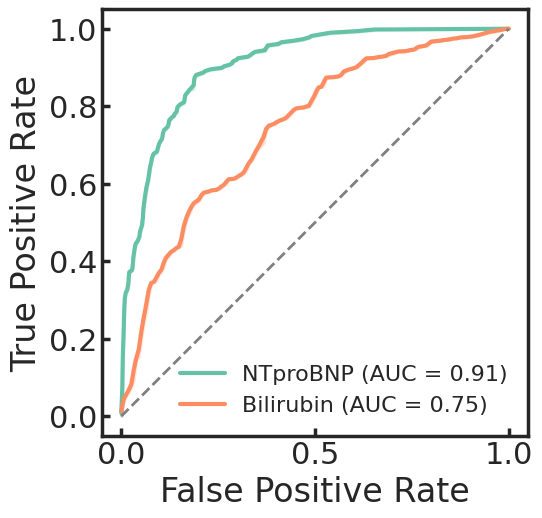

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import seaborn as sns

# i have 5 curves for auc
def get_auc_curve(y_true, y_score):
    y_true = np.vstack(y_true)
    y_score = np.vstack(y_score)

    mask = ~(np.all(y_true == -1, axis=1))
    y_true = y_true[mask]
    y_score = y_score[mask] 

    # replace -1 with 0
    y_true[y_true == -1] = 0

    # For binary, pick the positive class (assume class 1 is positive)
    y_true_bin = y_true[:, 1]
    y_score_bin = y_score[:, 1]

    # Compute ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_true_bin, y_score_bin)
    roc_auc = auc(fpr, tpr)
    return fpr, tpr, roc_auc

fpr_nt_pro, tpr_nt_pro, roc_auc_nt_pro = get_auc_curve(labels_list_nt_pro[0], output_list_nt_pro[0])
fpr_bilirubin, tpr_bilirubin, roc_auc_bilirubin = get_auc_curve(labels_list_bilirubin[0], output_list_bilirubin[0])
# fpr_bilirubin, tpr_bilirubin, roc_auc_bilirubin = zip(*[get_auc_curve(label, output) for label, output in zip(labels_list_bilirubin, output_list_bilirubin)])

# Convert lists of arrays to 2D arrays
# y_score_nt_pro = np.vstack(output_list_nt_pro[0])    # shape (n_samples, n_classes)
# y_true_nt_pro  = np.vstack(labels_list_nt_pro[0]) # shape (n_samples, n_classes)

# # Keep only rows where at least one label is not -1
# valid_mask_pro = ~(np.all(y_true_nt_pro == -1, axis=1))
# y_score_nt_pro = y_score_nt_pro[valid_mask_pro]
# y_true_nt_pro = y_true_nt_pro[valid_mask_pro]

# # Replace -1 with 0
# y_true_nt_pro[y_true_nt_pro == -1] = 0

# # For binary, pick the positive class (assume class 1 is positive)
# y_true_bin_pro = y_true_nt_pro[:, 1]
# y_score_bin_pro = y_score_nt_pro[:, 1]

# # Compute ROC curve and AUC
# fpr_nt_pro, tpr_nt_pro, _ = roc_curve(y_true_bin_pro, y_score_bin_pro)
# roc_auc_nt_pro = auc(fpr_nt_pro, tpr_nt_pro)


sns.set_style("white")
sns.set_context("poster")  # bigger fonts
palette = sns.color_palette("Set2")  # e.g., pastel but distinct colors

# Plot
plt.figure(figsize=(6,6))

# Plot all 5 curves for NTproBNP and Bilirubin with confidence intervals

#for i in range(5):
#    plt.plot(fpr_nt_pro[i], tpr_nt_pro[i], lw=2, alpha=0.7, color=palette[0])
#    plt.plot(fpr_bilirubin[i], tpr_bilirubin[i], lw=2, alpha=0.7, color=palette[1])

# Compute mean and std for NTproBNP
# mean_tpr_nt_pro = np.mean([np.interp(np.linspace(0, 1, 100), fpr_nt_pro[i], tpr_nt_pro[i]) for i in range(5)], axis=0)
# std_tpr_nt_pro = np.std([np.interp(np.linspace(0, 1, 100), fpr_nt_pro[i], tpr_nt_pro[i]) for i in range(5)], axis=0)
# mean_fpr = np.linspace(0, 1, 100)
# plt.plot(mean_fpr, mean_tpr_nt_pro, color=palette[0], lw=3, label=f"NTproBNP (AUC={np.mean(roc_auc_nt_pro):.2f}±{np.std(roc_auc_nt_pro):.2f})")
# plt.fill_between(mean_fpr, mean_tpr_nt_pro - std_tpr_nt_pro, mean_tpr_nt_pro + std_tpr_nt_pro, color=palette[0], alpha=0.2)

# Compute mean and std for Bilirubin
# mean_tpr_bilirubin = np.mean([np.interp(mean_fpr, fpr_bilirubin[i], tpr_bilirubin[i]) for i in range(5)], axis=0)
# std_tpr_bilirubin = np.std([np.interp(mean_fpr, fpr_bilirubin[i], tpr_bilirubin[i]) for i in range(5)], axis=0)
# plt.plot(mean_fpr, mean_tpr_bilirubin, color=palette[1], lw=3, label=f"Bilirubin (AUC={np.mean(roc_auc_bilirubin):.2f}±{np.std(roc_auc_bilirubin):.2f})")
# plt.fill_between(mean_fpr, mean_tpr_bilirubin - std_tpr_bilirubin, mean_tpr_bilirubin + std_tpr_bilirubin, color=palette[1], alpha=0.2)

sns.lineplot(x=fpr_nt_pro, y=tpr_nt_pro, lw=3,
             label=f"NTproBNP (AUC = {roc_auc_nt_pro:.2f})", color=palette[0])
sns.lineplot(x=fpr_bilirubin, y=tpr_bilirubin, lw=3,
             label=f"Bilirubin (AUC = {roc_auc_bilirubin:.2f})", color=palette[1])

plt.plot([0, 1], [0, 1], color="grey", lw=2, linestyle="--")  # diagonal

plt.gca().set_aspect(1.0, adjustable='box')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
# add inwards thicks
plt.tick_params(axis='both', which='both', direction='in', bottom=True, left=True, length=6)
# plt.title("NTproBNP")
plt.legend(loc="lower right", fontsize=16, frameon=False)
plt.tight_layout()
plt.savefig('figs/auc_nt_pro_bnp.svg')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

def print_auc_curve_3_class(output, labels, figname=''):
    # Convert lists of arrays to 2D arrays
    y_score = np.vstack(output)    # shape (n_samples, n_classes)
    y_true  = np.vstack(labels) # shape (n_samples, n_classes)

    # Only keep rows where at least one label is not -1
    valid_mask = ~(np.any(y_true == -1, axis=1))
    y_score = y_score[valid_mask]
    y_true  = y_true[valid_mask]

    n_classes = y_true.shape[1]

    # Colors for plotting
    palette = sns.color_palette("Set2")  # e.g., pastel but distinct colors

    plt.figure(figsize=(6,6))

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        label = "Below" if i == 0 else "Normal" if i == 1 else "Above"
        plt.plot(fpr, tpr, color=palette[i], lw=3, label=f"{label} (AUC = {roc_auc:.2f})")

    plt.gca().set_aspect(1.0, adjustable='box')

    plt.plot([0,1], [0,1], color="grey", lw=2, linestyle="--")  # diagonal
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.tick_params(axis='both', which='both', direction='in', bottom=True, left=True, length=6)
    plt.legend(loc="lower right", fontsize=16, frameon=False, title='Albumin')
    plt.tight_layout()
    plt.savefig(figname)

print_auc_curve_3_class(output_list_albumin, labels_list_albumin, "figs/albumin_roc_curve.svg")

NameError: name 'output_list_albumin' is not defined

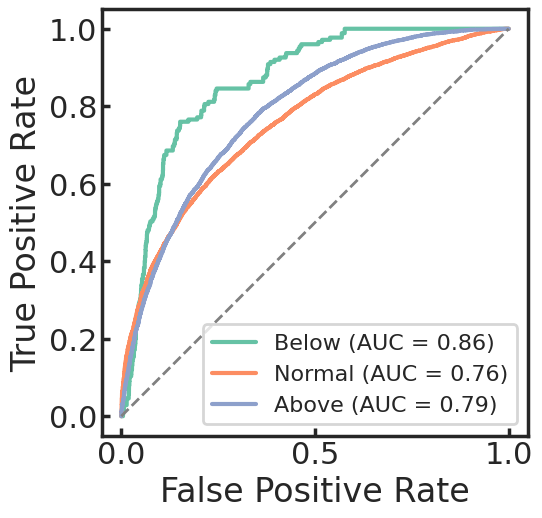

In [ ]:
print_auc_curve_3_class(output_list_urea, labels_list_urea, figname="figs/urea_roc_curve.pdf")